In [1]:
from pathlib import Path

BASE_DIR = Path("/content/poster_face_analysis_compare_JP_CN")

INPUT_DIR = BASE_DIR / "01_input"
COMBINED_DIR = BASE_DIR / "02_combined_data"
SUMMARY_DIR = BASE_DIR / "03_summary"
FIG_DIR = BASE_DIR / "04_figures"
STAT_DIR = BASE_DIR / "05_statistics"
R_DIR = BASE_DIR / "06_r_analysis"

for d in [
    INPUT_DIR,
    COMBINED_DIR,
    SUMMARY_DIR,
    FIG_DIR / "boxplot",
    FIG_DIR / "histogram",
    FIG_DIR / "pca",
    STAT_DIR,
    R_DIR
]:
    d.mkdir(parents=True, exist_ok=True)

print("フォルダ作成完了:")
print(BASE_DIR)

フォルダ作成完了:
/content/poster_face_analysis_compare_JP_CN


In [2]:
from google.colab import files
import shutil
from pathlib import Path

uploaded = files.upload()

for filename in uploaded.keys():
    src = Path("/content") / filename
    dst = INPUT_DIR / filename
    shutil.move(str(src), str(dst))
    print(f"uploaded: {filename} -> {dst}")

Saving poster_face_features_extended_JP_all.csv to poster_face_features_extended_JP_all.csv
Saving poster_face_features_extended_CN_all.csv to poster_face_features_extended_CN_all.csv
uploaded: poster_face_features_extended_JP_all.csv -> /content/poster_face_analysis_compare_JP_CN/01_input/poster_face_features_extended_JP_all.csv
uploaded: poster_face_features_extended_CN_all.csv -> /content/poster_face_analysis_compare_JP_CN/01_input/poster_face_features_extended_CN_all.csv


In [3]:
list(INPUT_DIR.iterdir())


[PosixPath('/content/poster_face_analysis_compare_JP_CN/01_input/poster_face_features_extended_CN_all.csv'),
 PosixPath('/content/poster_face_analysis_compare_JP_CN/01_input/poster_face_features_extended_JP_all.csv')]

In [4]:
import pandas as pd
from pathlib import Path

jp_path = INPUT_DIR / "poster_face_features_extended_JP_all.csv"
cn_path = INPUT_DIR / "poster_face_features_extended_CN_all.csv"

jp_df = pd.read_csv(jp_path)
cn_df = pd.read_csv(cn_path)

# 添加国家标签
jp_df["Country"] = "JP"
cn_df["Country"] = "CN"

# 确认 scene 名称统一
print("JP scenes:", jp_df["scene"].unique())
print("CN scenes:", cn_df["scene"].unique())

# 合并
combined_df = pd.concat([jp_df, cn_df], ignore_index=True)

# 把 Country 放到第一列
cols = combined_df.columns.tolist()
cols = ["Country"] + [c for c in cols if c != "Country"]
combined_df = combined_df[cols]

print("JP n =", len(jp_df))
print("CN n =", len(cn_df))
print("Combined n =", len(combined_df))

combined_df.head()

JP scenes: ['DIS' 'MED' 'PUB']
CN scenes: ['DIS' 'MED' 'PUB']
JP n = 151
CN n = 153
Combined n = 304


,Country,poster_id,filename,scene,num_faces_detected,image_width,image_height,fWHR,EFR,ESI,Mouth_Width,Smile_Arc_Angle,mouth_height_ratio,smile_index,mouth_corner_lift
0,JP,JP_DIS_001,JP_DIS_001_face.png,DIS,1,408,516,1.010919,0.012473,0.301296,0.416894,-0.997366,0.112197,3.788409,0.048085
1,JP,JP_DIS_002,JP_DIS_002_face.png,DIS,1,490,560,1.141971,0.015676,0.320004,0.406120,-0.995822,0.109788,4.304196,0.043905
2,JP,JP_DIS_003,JP_DIS_003_face.png,DIS,1,424,532,1.039812,0.014571,0.307231,0.378006,-0.993162,0.106193,3.650250,0.027326
3,JP,JP_DIS_004,JP_DIS_004_face.png,DIS,1,364,436,1.038293,0.017894,0.342977,0.444012,-0.999869,0.150953,3.023170,0.081010
4,JP,JP_DIS_005face,JP_DIS_005face.png,DIS,1,588,776,1.140407,0.014925,0.323656,0.420203,-0.999973,0.168410,2.908814,0.084075


In [5]:
features_basic = [
    "fWHR",
    "EFR",
    "ESI",
    "Mouth_Width",
    "Smile_Arc_Angle"
]

features_extended = [
    "fWHR",
    "EFR",
    "ESI",
    "Mouth_Width",
    "Smile_Arc_Angle",
    "mouth_height_ratio",
    "smile_index",
    "mouth_corner_lift"
]

print("Columns:")
print(combined_df.columns.tolist())

print("\nMissing values in features:")
print(combined_df[features_extended].isna().sum())

print("\nSample counts by Country and scene:")
count_table = combined_df.groupby(["Country", "scene"]).size().reset_index(name="n")
count_table

Columns:
['Country', 'poster_id', 'filename', 'scene', 'num_faces_detected', 'image_width', 'image_height', 'fWHR', 'EFR', 'ESI', 'Mouth_Width', 'Smile_Arc_Angle', 'mouth_height_ratio', 'smile_index', 'mouth_corner_lift']

Missing values in features:
fWHR                  0
EFR                   0
ESI                   0
Mouth_Width           0
Smile_Arc_Angle       0
mouth_height_ratio    0
smile_index           0
mouth_corner_lift     0
dtype: int64

Sample counts by Country and scene:


,Country,scene,n
0,CN,DIS,50
1,CN,MED,52
2,CN,PUB,51
3,JP,DIS,50
4,JP,MED,51
5,JP,PUB,50


In [6]:
combined_csv = COMBINED_DIR / "poster_face_features_extended_JP_CN_combined.csv"
combined_xlsx = COMBINED_DIR / "poster_face_features_extended_JP_CN_combined.xlsx"

combined_df.to_csv(combined_csv, index=False, encoding="utf-8-sig")
combined_df.to_excel(combined_xlsx, index=False)

# R 用的输入文件也保存一份
r_input_csv = R_DIR / "input_for_R_JP_CN_combined.csv"
combined_df.to_csv(r_input_csv, index=False, encoding="utf-8-sig")

print("保存完成:")
print(combined_csv)
print(combined_xlsx)
print(r_input_csv)

保存完成:
/content/poster_face_analysis_compare_JP_CN/02_combined_data/poster_face_features_extended_JP_CN_combined.csv
/content/poster_face_analysis_compare_JP_CN/02_combined_data/poster_face_features_extended_JP_CN_combined.xlsx
/content/poster_face_analysis_compare_JP_CN/06_r_analysis/input_for_R_JP_CN_combined.csv


In [7]:
sample_count = combined_df.groupby(["Country", "scene"]).size().reset_index(name="n")

sample_count_csv = SUMMARY_DIR / "sample_count_by_country_scene.csv"
sample_count_xlsx = SUMMARY_DIR / "sample_count_by_country_scene.xlsx"

sample_count.to_csv(sample_count_csv, index=False, encoding="utf-8-sig")
sample_count.to_excel(sample_count_xlsx, index=False)

sample_count

,Country,scene,n
0,CN,DIS,50
1,CN,MED,52
2,CN,PUB,51
3,JP,DIS,50
4,JP,MED,51
5,JP,PUB,50


In [8]:
summary_by_country = combined_df.groupby("Country")[features_extended].agg(
    ["count", "mean", "std", "min", "max"]
)

# 展开多层列名
summary_by_country_flat = summary_by_country.copy()
summary_by_country_flat.columns = [
    f"{feature}_{stat}" for feature, stat in summary_by_country_flat.columns
]
summary_by_country_flat = summary_by_country_flat.reset_index()

summary_country_csv = SUMMARY_DIR / "summary_by_country.csv"
summary_country_xlsx = SUMMARY_DIR / "summary_by_country.xlsx"

summary_by_country_flat.to_csv(summary_country_csv, index=False, encoding="utf-8-sig")
summary_by_country_flat.to_excel(summary_country_xlsx, index=False)

summary_by_country_flat

,Country,fWHR_count,fWHR_mean,fWHR_std,fWHR_min,fWHR_max,EFR_count,EFR_mean,EFR_std,EFR_min,...,smile_index_count,smile_index_mean,smile_index_std,smile_index_min,smile_index_max,mouth_corner_lift_count,mouth_corner_lift_mean,mouth_corner_lift_std,mouth_corner_lift_min,mouth_corner_lift_max
0,CN,153,1.084445,0.058807,0.965250,1.322428,153,0.012143,0.002870,0.004565,...,153,3.170029,0.750080,1.850000,6.297851,153,0.026178,0.020408,-0.021445,0.075113
1,JP,151,1.084989,0.057984,0.929583,1.234721,151,0.012981,0.003895,0.004716,...,151,2.965099,0.676155,1.862435,6.618761,151,0.057218,0.026923,-0.022601,0.115406


In [9]:
summary_by_country_scene = combined_df.groupby(["Country", "scene"])[features_extended].agg(
    ["count", "mean", "std", "min", "max"]
)

summary_by_country_scene_flat = summary_by_country_scene.copy()
summary_by_country_scene_flat.columns = [
    f"{feature}_{stat}" for feature, stat in summary_by_country_scene_flat.columns
]
summary_by_country_scene_flat = summary_by_country_scene_flat.reset_index()

summary_country_scene_csv = SUMMARY_DIR / "summary_by_country_scene.csv"
summary_country_scene_xlsx = SUMMARY_DIR / "summary_by_country_scene.xlsx"

summary_by_country_scene_flat.to_csv(summary_country_scene_csv, index=False, encoding="utf-8-sig")
summary_by_country_scene_flat.to_excel(summary_country_scene_xlsx, index=False)

summary_by_country_scene_flat

,Country,scene,fWHR_count,fWHR_mean,fWHR_std,fWHR_min,fWHR_max,EFR_count,EFR_mean,EFR_std,...,smile_index_count,smile_index_mean,smile_index_std,smile_index_min,smile_index_max,mouth_corner_lift_count,mouth_corner_lift_mean,mouth_corner_lift_std,mouth_corner_lift_min,mouth_corner_lift_max
0,CN,DIS,50,1.099678,0.065433,0.995889,1.322428,50,0.012964,0.003108,...,50,3.066078,0.567032,2.256754,4.867086,50,0.016916,0.022158,-0.021445,0.075113
1,CN,MED,52,1.081683,0.058794,0.965250,1.224054,52,0.011300,0.002334,...,52,3.455311,0.954403,1.850000,6.297851,52,0.025375,0.015865,-0.003782,0.061888
2,CN,PUB,51,1.072327,0.049006,0.977733,1.193704,51,0.012200,0.002932,...,51,2.981067,0.578185,1.851207,5.000000,51,0.036078,0.018487,0.008247,0.074545
3,JP,DIS,50,1.092921,0.054736,0.993740,1.234721,50,0.013656,0.003379,...,50,3.060552,0.594776,1.971992,4.555519,50,0.055901,0.027973,-0.022601,0.102585
4,JP,MED,51,1.074121,0.058494,0.960374,1.227474,51,0.011132,0.003093,...,51,2.831670,0.589098,1.953324,4.716991,51,0.059133,0.023525,-0.005780,0.101232
5,JP,PUB,50,1.088142,0.060064,0.929583,1.190943,50,0.014191,0.004442,...,50,3.005744,0.813730,1.862435,6.618761,50,0.056582,0.029423,-0.008543,0.115406


In [10]:
import shutil
from google.colab import files

zip_path = "/content/poster_face_analysis_compare_JP_CN_step1_combined"

shutil.make_archive(
    zip_path,
    "zip",
    BASE_DIR
)

files.download(zip_path + ".zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
# 确认样本数
print(combined_df.groupby(["Country", "scene"]).size())

# 确认特征列
features_extended = [
    "fWHR",
    "EFR",
    "ESI",
    "Mouth_Width",
    "Smile_Arc_Angle",
    "mouth_height_ratio",
    "smile_index",
    "mouth_corner_lift"
]

combined_df[features_extended].describe()

Country  scene
CN       DIS      50
         MED      52
         PUB      51
JP       DIS      50
         MED      51
         PUB      50
dtype: int64


,fWHR,EFR,ESI,Mouth_Width,Smile_Arc_Angle,mouth_height_ratio,smile_index,mouth_corner_lift
count,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000
mean,1.084715,0.012559,0.293799,0.389693,-0.926870,0.145345,3.068238,0.041596
std,0.058304,0.003437,0.052783,0.048260,0.084421,0.035109,0.720486,0.028450
min,0.929583,0.004565,0.133360,0.273537,-1.000000,0.063467,1.850000,-0.022601
25%,1.046410,0.010267,0.256943,0.351916,-0.991225,0.119039,2.577756,0.019771
50%,1.076728,0.012139,0.295159,0.386170,-0.961797,0.139130,2.934461,0.040086
75%,1.128205,0.014783,0.330154,0.424496,-0.890360,0.174021,3.375857,0.061924
max,1.322428,0.025912,0.464996,0.516536,-0.583929,0.238661,6.618761,0.115406


<Figure size 500x400 with 0 Axes>

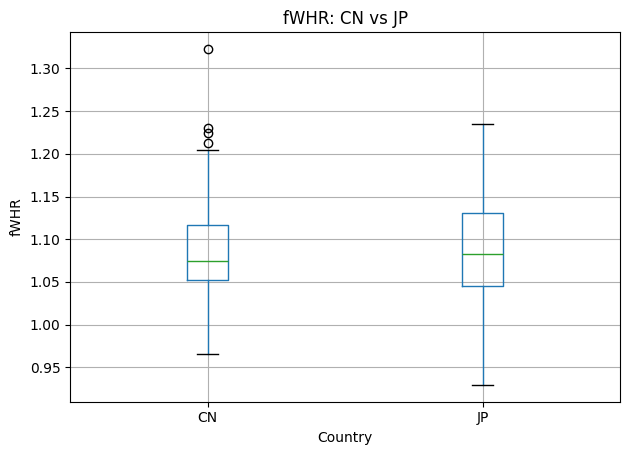

<Figure size 500x400 with 0 Axes>

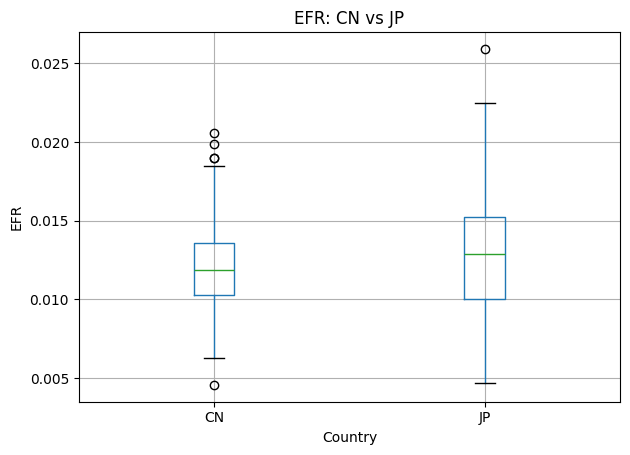

<Figure size 500x400 with 0 Axes>

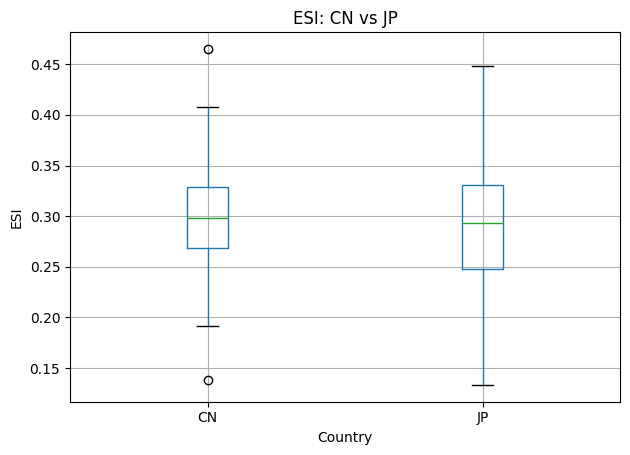

<Figure size 500x400 with 0 Axes>

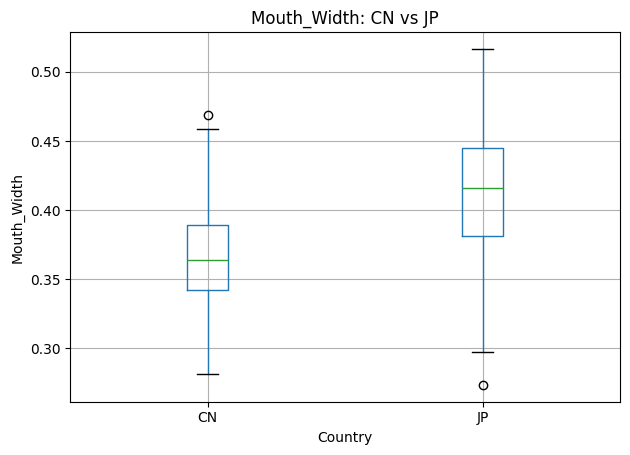

<Figure size 500x400 with 0 Axes>

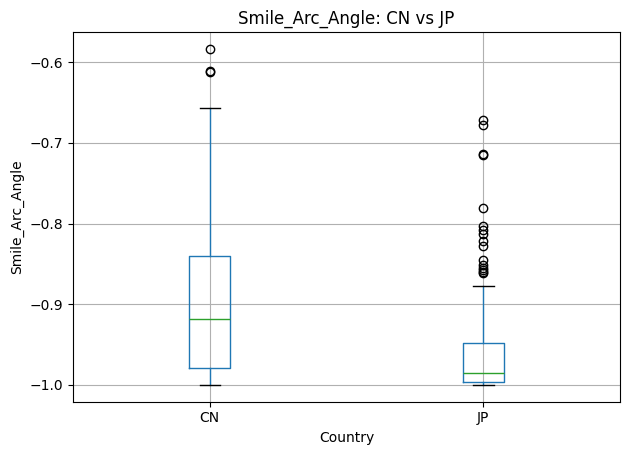

<Figure size 500x400 with 0 Axes>

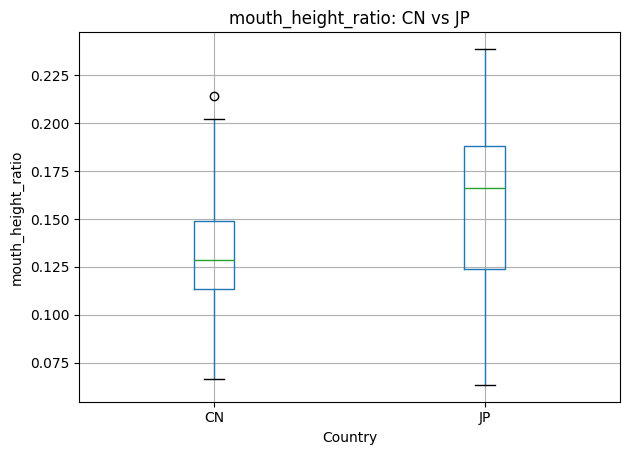

<Figure size 500x400 with 0 Axes>

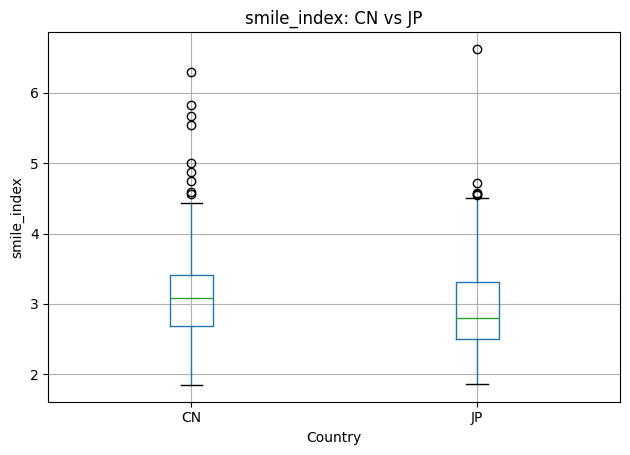

<Figure size 500x400 with 0 Axes>

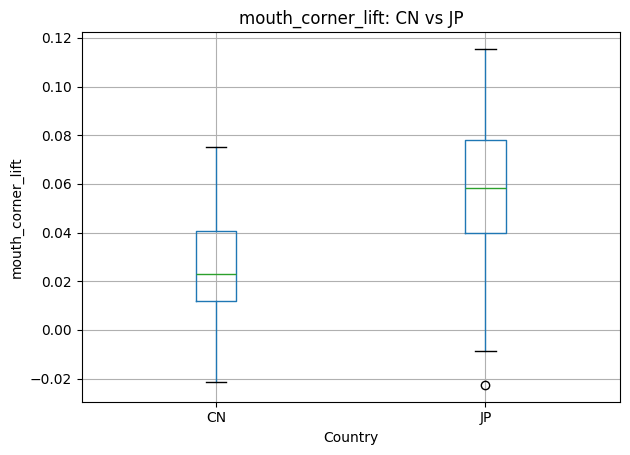

In [12]:
import matplotlib.pyplot as plt
from pathlib import Path

BOX_DIR = FIG_DIR / "boxplot"
BOX_DIR.mkdir(parents=True, exist_ok=True)

for feature in features_extended:
    plt.figure(figsize=(5, 4))
    combined_df.boxplot(column=feature, by="Country")
    plt.title(f"{feature}: CN vs JP")
    plt.suptitle("")
    plt.xlabel("Country")
    plt.ylabel(feature)
    plt.tight_layout()

    png_path = BOX_DIR / f"boxplot_{feature}_CN_JP.png"
    pdf_path = BOX_DIR / f"boxplot_{feature}_CN_JP.pdf"

    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.show()
    plt.close()

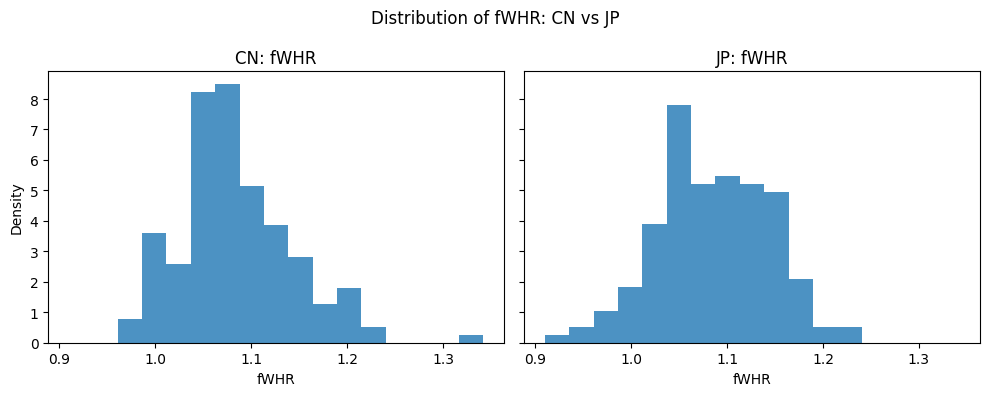

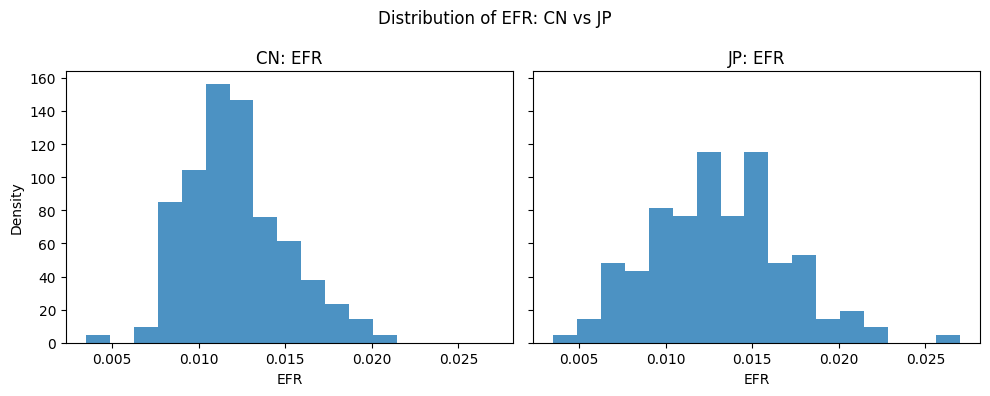

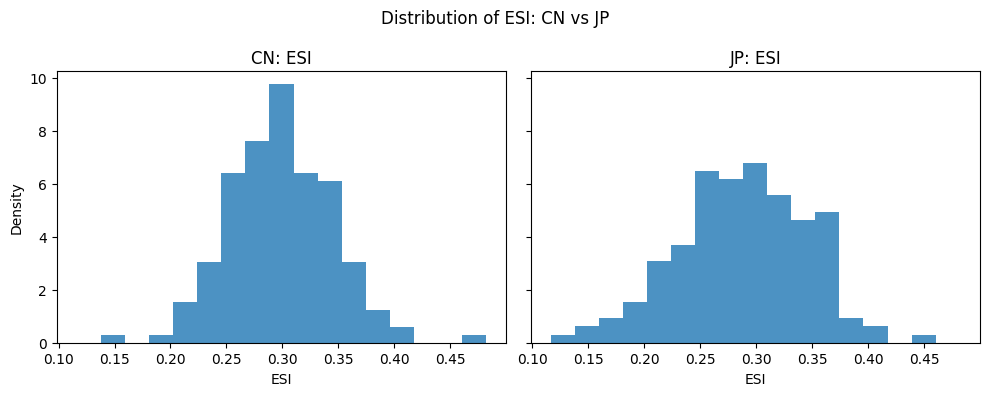

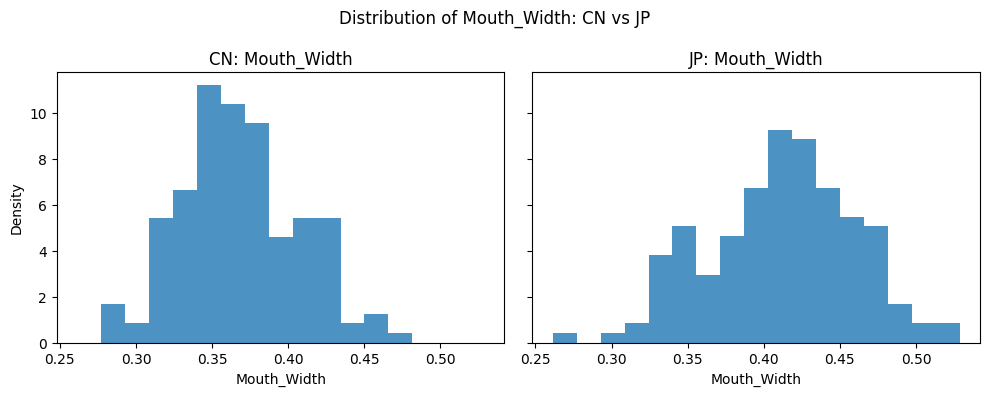

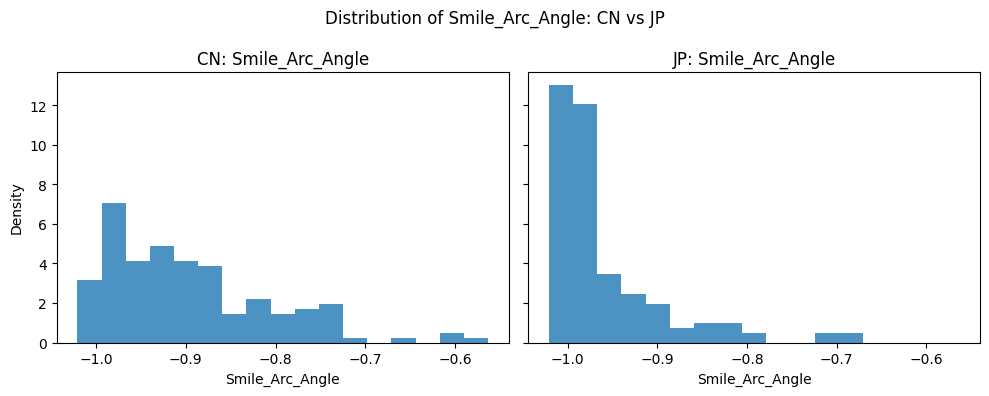

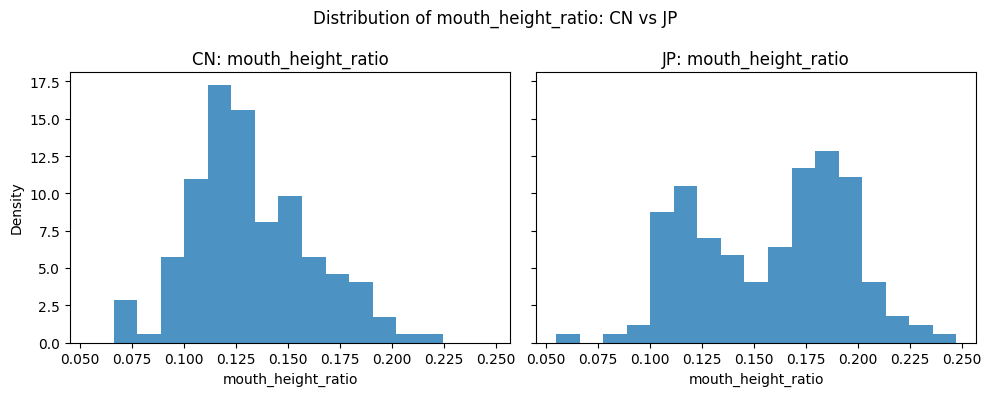

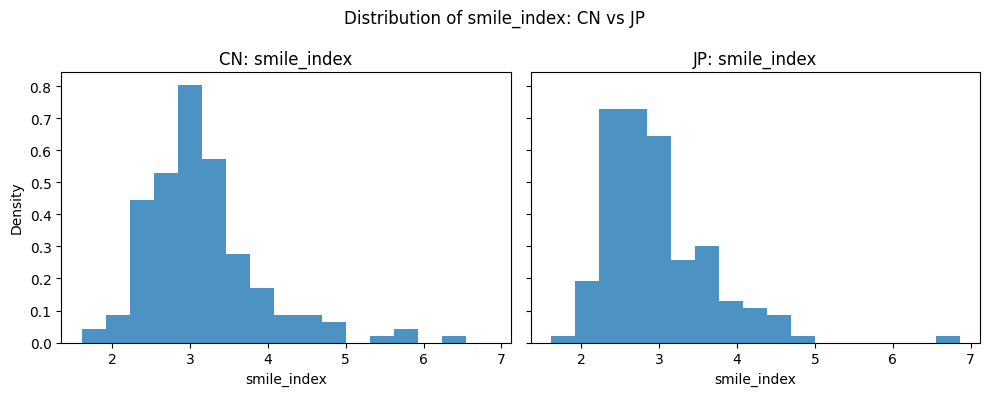

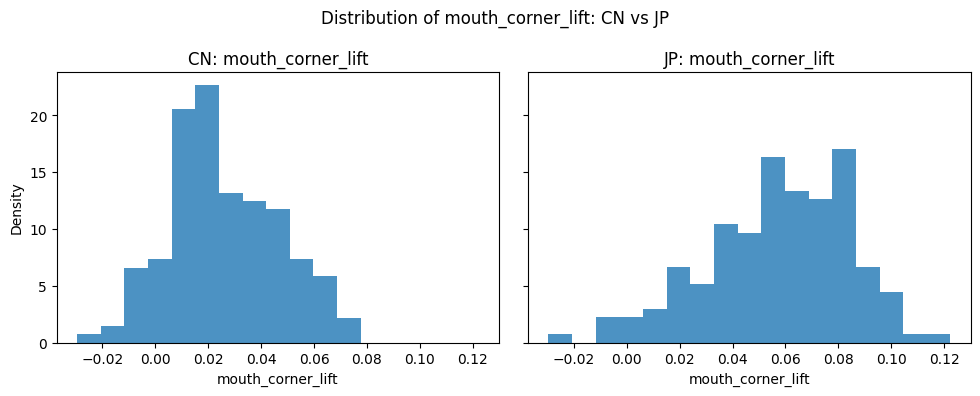

In [13]:
import numpy as np

HIST_DIR = FIG_DIR / "histogram"
HIST_DIR.mkdir(parents=True, exist_ok=True)

for feature in features_extended:
    jp_values = combined_df.loc[combined_df["Country"] == "JP", feature].dropna()
    cn_values = combined_df.loc[combined_df["Country"] == "CN", feature].dropna()

    all_values = np.concatenate([jp_values, cn_values])
    x_min = all_values.min()
    x_max = all_values.max()
    margin = (x_max - x_min) * 0.05
    bins = np.linspace(x_min - margin, x_max + margin, 18)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

    axes[0].hist(cn_values, bins=bins, density=True, alpha=0.8)
    axes[0].set_title(f"CN: {feature}")
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel("Density")

    axes[1].hist(jp_values, bins=bins, density=True, alpha=0.8)
    axes[1].set_title(f"JP: {feature}")
    axes[1].set_xlabel(feature)

    fig.suptitle(f"Distribution of {feature}: CN vs JP")
    plt.tight_layout()

    png_path = HIST_DIR / f"compare_hist_{feature}_CN_JP.png"
    pdf_path = HIST_DIR / f"compare_hist_{feature}_CN_JP.pdf"

    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.show()
    plt.close()

In [14]:
from scipy import stats
import pandas as pd
import numpy as np

def cohens_d(x, y):
    x = np.array(x.dropna(), dtype=float)
    y = np.array(y.dropna(), dtype=float)
    nx = len(x)
    ny = len(y)
    pooled_sd = np.sqrt(
        ((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / (nx + ny - 2)
    )
    if pooled_sd == 0:
        return np.nan
    return (np.mean(x) - np.mean(y)) / pooled_sd

test_results = []

for feature in features_extended:
    jp = combined_df.loc[combined_df["Country"] == "JP", feature].dropna()
    cn = combined_df.loc[combined_df["Country"] == "CN", feature].dropna()

    # Welch t-test
    t_stat, t_p = stats.ttest_ind(jp, cn, equal_var=False)

    # Mann-Whitney U
    u_stat, u_p = stats.mannwhitneyu(jp, cn, alternative="two-sided")

    # Cohen's d: JP - CN
    d = cohens_d(jp, cn)

    test_results.append({
        "feature": feature,
        "JP_n": len(jp),
        "CN_n": len(cn),
        "JP_mean": jp.mean(),
        "CN_mean": cn.mean(),
        "JP_std": jp.std(),
        "CN_std": cn.std(),
        "mean_diff_JP_minus_CN": jp.mean() - cn.mean(),
        "welch_t": t_stat,
        "welch_p": t_p,
        "mannwhitney_U": u_stat,
        "mannwhitney_p": u_p,
        "cohens_d_JP_minus_CN": d
    })

test_df = pd.DataFrame(test_results)

test_csv = STAT_DIR / "country_comparison_tests_CN_JP.csv"
test_xlsx = STAT_DIR / "country_comparison_tests_CN_JP.xlsx"

test_df.to_csv(test_csv, index=False, encoding="utf-8-sig")
test_df.to_excel(test_xlsx, index=False)

test_df

,feature,JP_n,CN_n,JP_mean,CN_mean,JP_std,CN_std,mean_diff_JP_minus_CN,welch_t,welch_p,mannwhitney_U,mannwhitney_p,cohens_d_JP_minus_CN
0,fWHR,151,153,1.084989,1.084445,0.057984,0.058807,0.000544,0.081218,9.353220e-01,11883.0,6.657770e-01,0.009316
1,EFR,151,153,0.012981,0.012143,0.003895,0.002870,0.000837,2.131284,3.395023e-02,13214.0,3.009103e-02,0.244959
2,ESI,151,153,0.288912,0.298623,0.058121,0.046617,-0.009711,-1.605813,1.094152e-01,10515.0,1.763857e-01,-0.184468
3,Mouth_Width,151,153,0.411673,0.368001,0.047536,0.038200,0.043671,8.822605,1.114186e-16,17619.0,2.426024e-15,1.013483
4,Smile_Arc_Angle,151,153,-0.957440,-0.896700,0.064928,0.090566,-0.060740,-6.726969,9.975985e-11,5951.5,2.725894e-13,-0.770019
5,mouth_height_ratio,151,153,0.158436,0.132426,0.036248,0.028675,0.026010,6.932839,2.758409e-11,16298.0,5.885278e-10,0.796477
6,smile_index,151,153,2.965099,3.170029,0.676155,0.750080,-0.204930,-2.502693,1.285779e-02,9327.0,3.704404e-03,-0.286889
7,mouth_corner_lift,151,153,0.057218,0.026178,0.026923,0.020408,0.031040,11.317192,1.070405e-24,18894.0,9.589980e-22,1.300517


In [20]:
import pandas as pd
import numpy as np

display_features = [
    "fWHR",
    "EFR",
    "ESI",
    "Mouth_Width",
    "mouth_height_ratio",
    "mouth_corner_lift",
    "Smile_Arc_Angle",
    "smile_index"
]

simple_test_df = test_df[test_df["feature"].isin(display_features)].copy()

# p 值显示格式
def format_p(p):
    if p < 0.001:
        return "< .001"
    else:
        return f"{p:.3f}"

# 方向
def direction(row):
    if row["welch_p"] >= 0.05:
        return "n.s."
    elif row["mean_diff_JP_minus_CN"] > 0:
        return "JP > CN"
    else:
        return "CN > JP"

# 效果量解释
def effect_label(d):
    ad = abs(d)
    if ad < 0.2:
        return "negligible"
    elif ad < 0.5:
        return "small"
    elif ad < 0.8:
        return "medium"
    else:
        return "large"

simple_test_df["Direction"] = simple_test_df.apply(direction, axis=1)
simple_test_df["p"] = simple_test_df["welch_p"].apply(format_p)
simple_test_df["Effect size"] = simple_test_df["cohens_d_JP_minus_CN"].apply(effect_label)

ppt_table = simple_test_df[[
    "feature",
    "JP_mean",
    "CN_mean",
    "Direction",
    "p",
    "cohens_d_JP_minus_CN",
    "Effect size"
]].copy()

ppt_table["JP_mean"] = ppt_table["JP_mean"].round(3)
ppt_table["CN_mean"] = ppt_table["CN_mean"].round(3)
ppt_table["cohens_d_JP_minus_CN"] = ppt_table["cohens_d_JP_minus_CN"].round(2)

ppt_table

,feature,JP_mean,CN_mean,Direction,p,cohens_d_JP_minus_CN,Effect size
0,fWHR,1.085,1.084,n.s.,0.935,0.01,negligible
1,EFR,0.013,0.012,JP > CN,0.034,0.24,small
2,ESI,0.289,0.299,n.s.,0.109,-0.18,negligible
3,Mouth_Width,0.412,0.368,JP > CN,< .001,1.01,large
4,Smile_Arc_Angle,-0.957,-0.897,CN > JP,< .001,-0.77,medium
5,mouth_height_ratio,0.158,0.132,JP > CN,< .001,0.80,medium
6,smile_index,2.965,3.170,CN > JP,0.013,-0.29,small
7,mouth_corner_lift,0.057,0.026,JP > CN,< .001,1.30,large


In [21]:
ppt_table_path = SUMMARY_DIR / "ppt_country_comparison_simple_table.xlsx"
ppt_table.to_excel(ppt_table_path, index=False)

ppt_table_path

PosixPath('/content/poster_face_analysis_compare_JP_CN/03_summary/ppt_country_comparison_simple_table.xlsx')

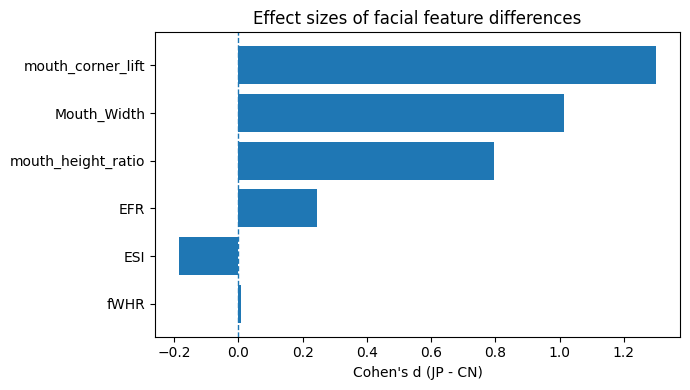

In [22]:
import matplotlib.pyplot as plt
from pathlib import Path

EFFECT_DIR = FIG_DIR / "effect_size"
EFFECT_DIR.mkdir(parents=True, exist_ok=True)

# 建议只画主要指标
main_features = [
    "Mouth_Width",
    "mouth_height_ratio",
    "mouth_corner_lift",
    "EFR",
    "ESI",
    "fWHR"
]

effect_df = test_df[test_df["feature"].isin(main_features)].copy()

# 为了让最强结果排上面
effect_df["abs_d"] = effect_df["cohens_d_JP_minus_CN"].abs()
effect_df = effect_df.sort_values("abs_d", ascending=True)

plt.figure(figsize=(7, 4))
plt.barh(effect_df["feature"], effect_df["cohens_d_JP_minus_CN"])
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Cohen's d (JP - CN)")
plt.title("Effect sizes of facial feature differences")

plt.tight_layout()

png_path = EFFECT_DIR / "cohens_d_JP_CN_main_features.png"
pdf_path = EFFECT_DIR / "cohens_d_JP_CN_main_features.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

PCA_DIR = FIG_DIR / "pca"
PCA_DIR.mkdir(parents=True, exist_ok=True)

pca_features = [
    "fWHR",
    "EFR",
    "ESI",
    "Mouth_Width",
    "mouth_height_ratio",
    "smile_index",
    "mouth_corner_lift"
]

pca_data = combined_df.dropna(subset=pca_features).copy()

X = pca_data[pca_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
scores = pca.fit_transform(X_scaled)

pca_data["PCA1_combined"] = scores[:, 0]
pca_data["PCA2_combined"] = scores[:, 1]

explained = pca.explained_variance_ratio_

print("Explained variance ratio:")
print("PCA1:", explained[0])
print("PCA2:", explained[1])
print("Total:", explained[0] + explained[1])

Explained variance ratio:
PCA1: 0.4186698942998091
PCA2: 0.22846986838196176
Total: 0.6471397626817709


In [16]:
# PCA scores
pca_scores_csv = COMBINED_DIR / "poster_face_pca_scores_combined_JP_CN.csv"
pca_scores_xlsx = COMBINED_DIR / "poster_face_pca_scores_combined_JP_CN.xlsx"

pca_data.to_csv(pca_scores_csv, index=False, encoding="utf-8-sig")
pca_data.to_excel(pca_scores_xlsx, index=False)

# PCA loadings
loadings_combined = pd.DataFrame(
    pca.components_.T,
    columns=["PCA1_loading", "PCA2_loading"],
    index=pca_features
).reset_index().rename(columns={"index": "feature"})

loading_csv = COMBINED_DIR / "poster_face_pca_loadings_combined_JP_CN.csv"
loading_xlsx = COMBINED_DIR / "poster_face_pca_loadings_combined_JP_CN.xlsx"

loadings_combined.to_csv(loading_csv, index=False, encoding="utf-8-sig")
loadings_combined.to_excel(loading_xlsx, index=False)

loadings_combined

,feature,PCA1_loading,PCA2_loading
0,fWHR,-0.115946,-0.018450
1,EFR,-0.299583,0.626369
2,ESI,-0.377006,0.568475
3,Mouth_Width,0.461483,0.051044
4,mouth_height_ratio,0.507424,0.300398
5,smile_index,-0.329347,-0.355770
6,mouth_corner_lift,0.419235,0.254445


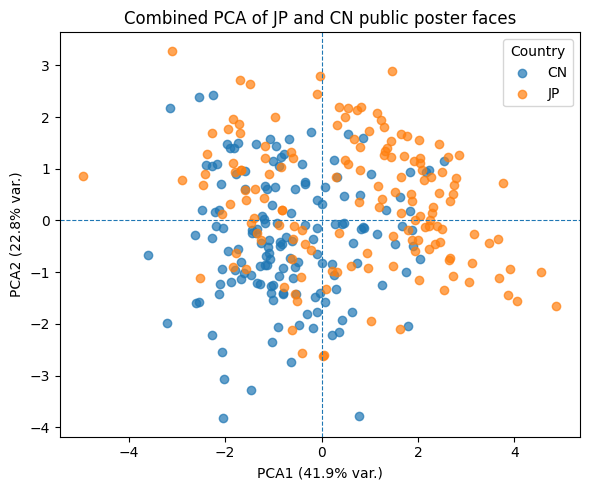

In [17]:
plt.figure(figsize=(6, 5))

for country, group_df in pca_data.groupby("Country"):
    plt.scatter(
        group_df["PCA1_combined"],
        group_df["PCA2_combined"],
        label=country,
        alpha=0.7
    )

plt.axhline(0, linestyle="--", linewidth=0.8)
plt.axvline(0, linestyle="--", linewidth=0.8)

plt.xlabel(f"PCA1 ({explained[0]*100:.1f}% var.)")
plt.ylabel(f"PCA2 ({explained[1]*100:.1f}% var.)")
plt.title("Combined PCA of JP and CN public poster faces")
plt.legend(title="Country")
plt.tight_layout()

png_path = PCA_DIR / "combined_pca_JP_CN_by_country.png"
pdf_path = PCA_DIR / "combined_pca_JP_CN_by_country.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()
plt.close()

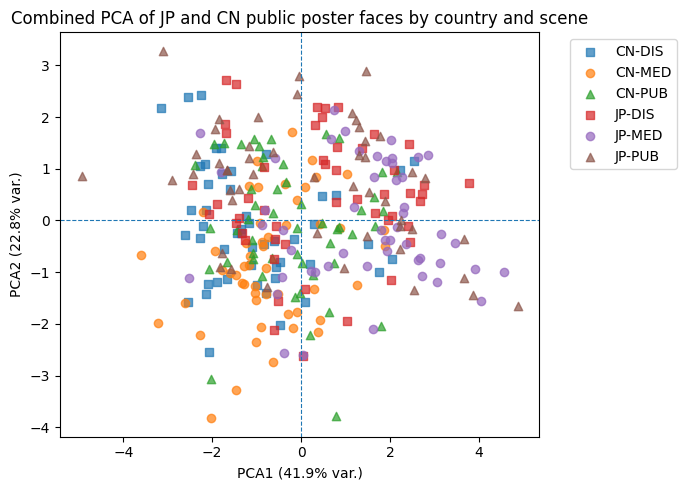

In [18]:
markers = {
    "MED": "o",
    "DIS": "s",
    "PUB": "^"
}

plt.figure(figsize=(7, 5))

for (country, scene), group_df in pca_data.groupby(["Country", "scene"]):
    plt.scatter(
        group_df["PCA1_combined"],
        group_df["PCA2_combined"],
        label=f"{country}-{scene}",
        marker=markers.get(scene, "o"),
        alpha=0.7
    )

plt.axhline(0, linestyle="--", linewidth=0.8)
plt.axvline(0, linestyle="--", linewidth=0.8)

plt.xlabel(f"PCA1 ({explained[0]*100:.1f}% var.)")
plt.ylabel(f"PCA2 ({explained[1]*100:.1f}% var.)")
plt.title("Combined PCA of JP and CN public poster faces by country and scene")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

png_path = PCA_DIR / "combined_pca_JP_CN_by_country_scene.png"
pdf_path = PCA_DIR / "combined_pca_JP_CN_by_country_scene.pdf"

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()
plt.close()

In [23]:
import shutil
from google.colab import files

zip_path = "/content/poster_face_analysis_compare_JP_CN_step2_comparison"

shutil.make_archive(
    zip_path,
    "zip",
    BASE_DIR
)

files.download(zip_path + ".zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>